# Глубинное обучение, ИИ ВШЭ

## Домашнее задание 2. Классификация при помощи CNN.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этом задании вам предстоит познакомиться со сверточными сетями и их обучением для классификации изображений с использованием библиотеки PyTorch.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from torchmetrics.functional import accuracy
from tqdm import tqdm

plt.rcParams.update({"font.size": 16})
sns.set_style("whitegrid")

In [1]:
pip install torchmetrics

## 0. Загрузка данных

Работать мы будем с набором данных [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html). CIFAR10 представляет собой набор изображений 32х32 пикселя, разделенных на 10 классов.

![title](https://pytorch.org/tutorials/_images/cifar10.png)




Набор данных уже определен в <code>torchvision.datasets</code>, так что возьмем его оттуда.



In [25]:
# Для тру нормализации
# mean = [0.4914, 0.4822, 0.4465]
# std = [0.2470, 0.2435, 0.2616]
# Тут взяты значения как в одном из туториалов пайторча :)


def get_cifar10_data(batch_size, transform_train):
    torch.manual_seed(0)
    np.random.seed(0)

    transform_test = transforms.Compose(
        [
            transforms.ToTensor(),
            # Переводим цвета пикселей в отрезок [-1, 1]
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    )

    # Загружаем данные
    trainvalset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform_train
    )
    testset = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform_test
    )

    # В датасете определено разбиение только на train и test,
    # так что валидацию дополнительно выделяем из обучающей выборки
    train_idx, valid_idx = train_test_split(
        np.arange(len(trainvalset)), test_size=0.3, shuffle=True, random_state=0
    )
    trainset = torch.utils.data.Subset(trainvalset, train_idx)
    valset = torch.utils.data.Subset(trainvalset, valid_idx)

    train_loader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, num_workers=2 # по умолчанию было 2
    )
    val_loader = torch.utils.data.DataLoader(
        valset, batch_size=batch_size, shuffle=False, num_workers=2 # по умолчанию было 2
    )
    test_loader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=2 # по умолчанию было 2
    )

    return train_loader, val_loader, test_loader

In [26]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(
    batch_size=64, transform_train=transform
)

Посмотрим на изображения:

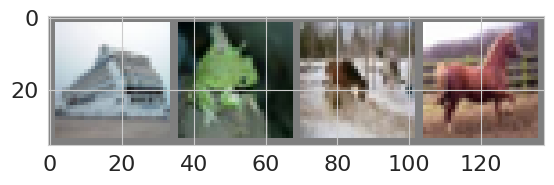

ship frog horse horse


In [27]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))

classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)
print(*[classes[labels[i]] for i in range(4)])

## 1. Задание сверточной сети (3 балла)

Теперь нам нужно задать сверточную нейронную сеть, которую мы будем обучать классифицировать изображения.

Используем сеть, основанную на одном блоке архитектуры, похожей на ResNet. Обратите внимание, это не ResNet 1 в 1.

<img src="https://i.ibb.co/2hg962h/basic-block.png" width="500"/>

__Указания:__

- Все сверточные слои должны иметь 32 выходных канала, а также не должны изменять ширину и высоту изображения.
- Выход блока сократите до размерности 32х4х4, применив average pooling.
- Для получения итоговых логитов, распрямите выход пулинга в вектор из 512 элементов, а затем пропустите его через линейный слой.

**Задание 1.1 (3 балла).**

Определите архитектуру сети соответственно схеме и указаниям выше.

Ключевые слова: <code>Conv2d</code>, <code>BatchNorm2d</code>, <code>AvgPool2d</code>.

In [6]:
n_classes = 10

class BasicBlockNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1_c3 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=1)
        self.conv3_c3 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.batch_norm_1 = nn.BatchNorm2d(num_features=32)
        self.batch_norm_2 = nn.BatchNorm2d(num_features=32)
        self.relu = nn.ReLU()
        self.conv3_c32 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.pooling = nn.AvgPool2d(kernel_size=8, stride=8)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(in_features=512, out_features=n_classes)

    def forward(self, x):
        out1 = self.conv3_c3(x)
        out2 = self.conv1_c3(x)

        out1 = self.batch_norm_1(out1)
        out1 = self.relu(out1)
        out1 = self.conv3_c32(out1)
        out1= self.batch_norm_2(out1)

        out = out1 + out2
        out = self.relu(out)
        out = self.pooling(out)
        out = self.flatten(out)
        out = self.fc(out)

        return out

In [7]:
net = BasicBlockNet()
net

BasicBlockNet(
  (conv1_c3): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
  (conv3_c3): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batch_norm_1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm_2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (conv3_c32): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): AvgPool2d(kernel_size=8, stride=8, padding=0)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=512, out_features=10, bias=True)
)

Проверим, что выход сети имеет корректную размерность:

In [8]:
assert net(torch.zeros((10, 3, 32, 32))).shape == (10, 10)

Чтобы проводить вычисления на GPU, в PyTorch необходимо руками перекладывать объекты, с которыми вы хотите проводить вычисления, на графический ускоритель. Это делается следующим образрм:

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [10]:
net = net.to(device)

Подключение GPU в google.colab:

**Среда выполнения** -> **Сменить среду выполнения** -> **Аппаратный ускоритель** -> **GPU**

## 2. Обучение и тестирование модели (3 балла)

**Задание 2.1 (2 балла).** Переходим к обучению модели. Заполните пропуски в функциях <code>test</code> и <code>train_epoch</code>. В качестве функции потерь будем использовать [кросс-энтропию](https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html), а в качестве метрики качества accuracy.

In [11]:
def test(model, loader):
    loss_log = []
    acc_log = []
    model.eval()

    pbar = tqdm(train_loader, desc=f"validating epoch")

    for data, target in pbar:

        with torch.no_grad():
            predictions = model(data.to(device))
            target_computed = target.to(device)
            loss = nn.functional.cross_entropy(predictions, target_computed)
            loss_log.append(loss.item())

            acc = accuracy(
                preds=predictions,
                target=target_computed,
                task="multiclass",
                num_classes=10
            )
            acc_log.append(acc.item())

    return np.mean(loss_log), np.mean(acc_log)


def train_epoch(model, optimizer, train_loader):
    loss_log = []
    acc_log = []
    model.train()

    pbar = tqdm(train_loader, desc=f"training epoch")

    for data, target in pbar:
        predictions = model(data.to(device))
        target_computed = target.to(device)
        loss = nn.functional.cross_entropy(predictions, target_computed)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_log.append(loss.item())

        with torch.no_grad():
            acc = accuracy(
                preds=predictions,
                target=target_computed,
                task="multiclass",
                num_classes=10
            )
            acc_log.append(acc.item())

    return loss_log, acc_log


def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")

        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

Запустим обучение модели. В качестве оптимизатора будем использовать стохастический градиентный спуск, который является де-факто стандартом в задачах компьютерного зрения (наравне с <code>Adam</code>).

__Замечание:__ Для достижения наилучшего качества в нашем случае потребуется обучать модель несколько сотен эпох. Однако в целях экономии вашего времени и сил, во всех экспериментах мы ограничимся 20 эпохами.

In [12]:
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9, fused=True)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader
)

validating epoch: 100%|██████████| 547/547 [00:10<00:00, 52.15it/s]


Epoch 0
 train loss: 1.4424640640916075, train acc: 0.48828431054050786
 val loss: 1.2302297209908801, val acc: 0.5621613018909364



validating epoch: 100%|██████████| 547/547 [00:10<00:00, 53.99it/s]


Epoch 1
 train loss: 1.1446528483788319, train acc: 0.599581320172472
 val loss: 1.1423830079422137, val acc: 0.6065919627001343



validating epoch: 100%|██████████| 547/547 [00:10<00:00, 53.17it/s]


...

Epoch 17
 train loss: 0.7467862571942087, train acc: 0.7414631757483404
 val loss: 0.7193960893415664, val acc: 0.7527585531937356



validating epoch: 100%|██████████| 547/547 [00:09<00:00, 58.63it/s]


Epoch 18
 train loss: 0.744677855992448, train acc: 0.7389249803815071
 val loss: 0.7496617361766983, val acc: 0.7416631300445012



validating epoch: 100%|██████████| 547/547 [00:10<00:00, 53.40it/s]

Epoch 19
 train loss: 0.7373065278887531, train acc: 0.743405588911046
 val loss: 0.7104702528150687, val acc: 0.7512078871456753



Посчитайте точность на тестовой выборке:

In [13]:
test_loss, test_accuracy = test(net, test_loader)
print(f"test loss: {test_loss}, test accuracy: {test_accuracy}")

validating epoch: 100%|██████████| 547/547 [00:10<00:00, 52.51it/s]

test loss: 0.7105356217302395, test accuracy: 0.7511752415618688


Если вы все сделали правильно, у вас должна была получиться точность $\ge 67\%$.

**Задание 2.2 (1 балл).** Постройте графики зависимости функции потерь и точности классификации от номера шага оптимизатора. На каждом графике расположите данные и для обучающей и для валидационной выборки, итого у вас должно получиться два графика. Обратите внимание, что на обучающей выборке эти данные считаются по каждому батчу, на валидационной же они считаются по всей выборке раз в эпоху.

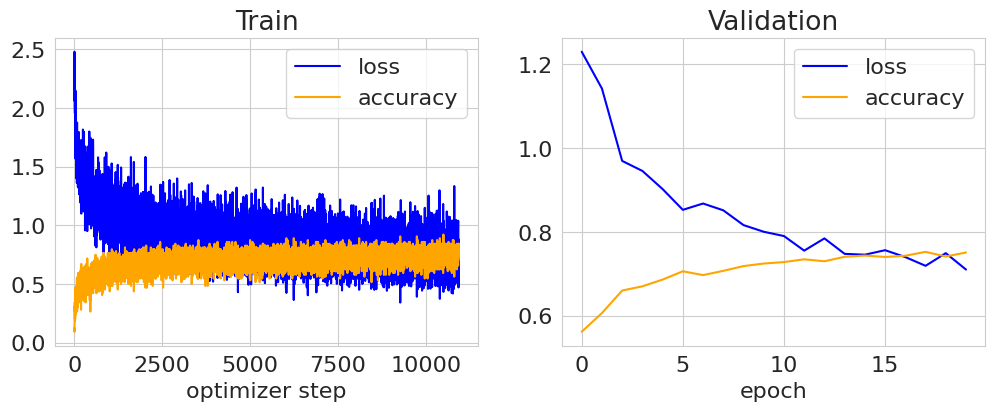

In [14]:
plt.figure(figsize=(2 * 6, 4))

# train
plt.subplot(1, 2, 1)
plt.plot(train_loss_log, color="blue", label="loss")
plt.plot(train_acc_log, color="orange", label="accuracy")
plt.legend()
plt.xlabel("optimizer step")
plt.title("Train")

# validation
plt.subplot(1, 2, 2)
plt.plot(val_loss_log, color="blue", label="loss")
plt.plot(val_acc_log, color="orange", label="accuracy")
plt.legend()
plt.xlabel("epoch")
plt.title("Validation")

plt.show()

## 3. Расписание длины шага (2 балла)

С курса "Машинное обучение 1" вы уже должны знать, что сходимость стохастического градиентного спуска мы можем теоретически гарантировать только если будем определенным образом со временем уменьшать длину шага. На практике при обучении нейронных сетей такая техника оказывается очень полезной, однако теоретически обоснованными способами уменьшения длины шага фантазия не ограничивается.

Одним из простейших способов является кусочно постоянная функция: на нескольких фиксированных эпохах уменьшаем длину шага в константу раз.

In [17]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

validating epoch: 100%|██████████| 547/547 [00:10<00:00, 52.77it/s]


Epoch 0
 train loss: 1.5126406089479352, train acc: 0.46056003522611405
 val loss: 1.2908368072518484, val acc: 0.5389543614287263



validating epoch: 100%|██████████| 547/547 [00:10<00:00, 53.42it/s]


Epoch 1
 train loss: 1.182380325833448, train acc: 0.5838379798903108
 val loss: 1.1037232479186119, val acc: 0.6184953642937557



validating epoch: 100%|██████████| 547/547 [00:09<00:00, 59.17it/s]


...

Epoch 17
 train loss: 0.6951128593092645, train acc: 0.7589122486288848
 val loss: 0.68632785602723, val acc: 0.7639437516167134



validating epoch: 100%|██████████| 547/547 [00:10<00:00, 53.05it/s]


Epoch 18
 train loss: 0.6932198350782586, train acc: 0.7602466375343978
 val loss: 0.6853292901511602, val acc: 0.7634703904880684



validating epoch: 100%|██████████| 547/547 [00:09<00:00, 57.23it/s]

Epoch 19
 train loss: 0.6939999350573071, train acc: 0.7610913423559129
 val loss: 0.6852814734962784, val acc: 0.76350711675623



Посчитайте точность на тестовой выборке:

In [18]:
test_loss, test_accuracy = test(net, test_loader)
print(f"test loss: {test_loss}, test accuracy: {test_accuracy}")

validating epoch: 100%|██████████| 547/547 [00:11<00:00, 49.04it/s]

test loss: 0.685272920938035, test accuracy: 0.763511197440585


**Задание 3.0 (0.5 баллов).** Здесь может возникнуть вопрос: а что будет, если мы не будем уменьшать длину шага в процессе обучения, а сразу возьмем констатную, равную значению нашей кусочно-постоянной функции на последних эпохах, то есть $0.001$ в нашем случае. Запустите обучение и проверьте, что в таком случае мы получим худшее качество на тестовой выборке.

In [19]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader
)

validating epoch: 100%|██████████| 547/547 [00:10<00:00, 53.61it/s]


Epoch 0
 train loss: 1.7979102073683382, train acc: 0.371437548991749
 val loss: 1.5792632211932753, val acc: 0.4449350352805973



validating epoch: 100%|██████████| 547/547 [00:09<00:00, 59.15it/s]


Epoch 1
 train loss: 1.5005297244575821, train acc: 0.4743732045076011
 val loss: 1.41762157419264, val acc: 0.5037868895739916



validating epoch: 100%|██████████| 547/547 [00:10<00:00, 53.71it/s]


...

Epoch 17
 train loss: 0.9520968407991818, train acc: 0.6689572995715865
 val loss: 0.9312910969340169, val acc: 0.6779062744686329



validating epoch: 100%|██████████| 547/547 [00:10<00:00, 53.47it/s]


Epoch 18
 train loss: 0.9451780152495208, train acc: 0.6750375424704125
 val loss: 0.9249312523514087, val acc: 0.6791998563126629



validating epoch: 100%|██████████| 547/547 [00:10<00:00, 54.00it/s]

Epoch 19
 train loss: 0.9348246147907194, train acc: 0.6759475385685072
 val loss: 0.9229076249181025, val acc: 0.6768779380883769



In [20]:
test_loss, test_accuracy = test(net, test_loader)
print(f"test loss: {test_loss}, test accuracy: {test_accuracy}")

validating epoch: 100%|██████████| 547/547 [00:09<00:00, 55.43it/s]

test loss: 0.9229446215864945, test accuracy: 0.6768330504515053


**Задание 3.1 (1.5 балла).** Изучите, какие еще способы уменьшения длины шага представлены в <code>torch.optim.lr_scheduler</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними. Удалось ли добиться улучшения качества на тестовой выборке?

### [LinearLR](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LinearLR.html#linearlr)

В течение первых total_iters эпох, коэффициент start_factor, на который домножается изначальный learning rate, линейно увеличивается с коэффициентом k: $$k=\frac{end\_factor - start\_factor}{total\_iters}$$

In [30]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.05, momentum=0.9, fused=True)
scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.5, end_factor=1, total_iters=4)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

test_loss, test_accuracy = test(net, test_loader)
print(f"test loss: {test_loss}, test accuracy: {test_accuracy}")

validating epoch: 100%|██████████| 547/547 [00:09<00:00, 58.91it/s]


Epoch 0
 train loss: 1.4756590579066025, train acc: 0.47268787543995944
 val loss: 1.2549155501604516, val acc: 0.5625571297989032



validating epoch: 100%|██████████| 547/547 [00:10<00:00, 52.61it/s]


Epoch 1
 train loss: 1.168269499455335, train acc: 0.588445090070721
 val loss: 1.0556316671031485, val acc: 0.6295867067586352



validating epoch: 100%|██████████| 547/547 [00:10<00:00, 54.38it/s]


...

Epoch 18
 train loss: 0.7457179789460338, train acc: 0.7410142987258256
 val loss: 0.7273203255489495, val acc: 0.7486329655106805



validating epoch: 100%|██████████| 547/547 [00:13<00:00, 40.34it/s]


Epoch 19
 train loss: 0.7405926758454094, train acc: 0.7448746409451068
 val loss: 0.7764779316223953, val acc: 0.7292782058445584



validating epoch: 100%|██████████| 547/547 [00:11<00:00, 48.88it/s]

test loss: 0.7764717861328961, test accuracy: 0.7292741250512369


### [ReduceLROnPlateau](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html#torch.optim.lr_scheduler.ReduceLROnPlateau)

Когда качество на валидационной выборке перестает увеличиваться в течение заданного кол-ва эпох, скорость обучения уменьшается.

In [32]:
def train_ReduceLROnPlateau(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")

        if scheduler is not None:
            scheduler.step(val_acc)

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

In [36]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9, fused=True)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train_ReduceLROnPlateau(
    net, optimizer, 30, train_loader, val_loader, scheduler
)

test_loss, test_accuracy = test(net, test_loader)
print(f"test loss: {test_loss}, test accuracy: {test_accuracy}")

validating epoch: 100%|██████████| 547/547 [00:09<00:00, 56.23it/s]


Epoch 0
 train loss: 1.4851644826981443, train acc: 0.4673258357117773
 val loss: 1.2482121190161766, val acc: 0.5578071951212351



validating epoch: 100%|██████████| 547/547 [00:10<00:00, 54.61it/s]


Epoch 1
 train loss: 1.1889627754579297, train acc: 0.5822383455210237
 val loss: 1.0558132990186786, val acc: 0.6333042243716922



validating epoch: 100%|██████████| 547/547 [00:11<00:00, 49.52it/s]


...

Epoch 28
 train loss: 0.6053326857809175, train acc: 0.7925821037135569
 val loss: 0.5897267066909364, val acc: 0.7970055824441927



validating epoch: 100%|██████████| 547/547 [00:10<00:00, 53.47it/s]


Epoch 29
 train loss: 0.6028614585207847, train acc: 0.7921944371743002
 val loss: 0.5902440655275062, val acc: 0.7965852703211295



validating epoch: 100%|██████████| 547/547 [00:10<00:00, 52.51it/s]

test loss: 0.5902616762482924, test accuracy: 0.7965730281590979


Your answers here:

## 4. Аугментации данных (2 балла)

Еще одной стандартной техникой, применяющейся в глубинном обучении, а особенно часто в компьютерном зрении, являются аугментации данных. Суть аугментаций состоит в том, что мы можем некоторым синтетическим образом видоизменять объекты обучающей выборки, тем самым расширяя ее, а также делая итоговую модель более устойчивой к таким изменениям.

Простейшая аугментация, которую можно применить к картинкам — разворот картинки по горизонтальной оси. То есть при обучении модели с вероятностью $0.5$ мы будем разворачивать картинку из обучающей выборки.

In [ ]:
dataiter = iter(train_loader)
images, labels = dataiter.next()

imshow(torchvision.utils.make_grid(images[:4]))

imshow(torchvision.utils.make_grid(transforms.functional.hflip(images[:4])))

Наиболее удобным способом работы с аугментациями в PyTorch является их задание в списке <code>transforms</code>, который затем передается в загрузчик данных. Обучим нашу сеть, применяя горизонтальные повороты:

In [ ]:
transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

train_loader, val_loader, test_loader = get_cifar10_data(
    batch_size=64, transform_train=transform
)

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

Посчитайте точность на тестовой выборке:

In [ ]:
# <your code here>

**Задание 4.1 (2 балла).** Изучите, какие еще способы аугментаций изображений представлены в <code>torchvision.transforms</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними (по отдельности и вместе). Удалось ли добиться улучшения качества на тестовой выборке?

In [ ]:
# <your code here>

Your answers here:

## Бонус. Логирование в wandb (1 балл)

На практике специалиста по глубинному обучению часто встречаются ситуации, когда нейросеть учится на каком-то удаленном сервере. И обычно вам хочется отслеживать прогресс обучения, особенно когда время обучения модели исчисляется днями или неделями. Для таких целей существует несколько инструментов. Вероятно, самый популярный из них — [wandb](https://wandb.ai/site).

Ваша задача состоит в том, чтобы разобраться как им пользоваться, и повторить задания 2.1 и 2.2 с его использованием. Обучение вы можете запускать в этом же ноутбуке, но теперь вам необходимо через wandb логировать значения функции потерь и точности на обучающей выборке и на валидационной. Результатом работы должны быть ваш код и публичная ссылка на страничку с графиками, идентичными графикам в задании 2.2.

Если вас смущает, что WandB грозится забанить вас, то можете разобраться с любым его аналогом и приложить ссылку на аналог.

In [ ]:
# <your code here>